In [1]:
# In[1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # For enhanced visualizations
import os

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

# Assistant
This error occurs because you're trying to use Google Colab-specific code in a non-Colab environment. The `google.colab` module is only available when running code in Google Colab.

Would you like me to provide the corrected code?

In [2]:
# In[2]:
# b. Read the student dataset from CSV
# Try to read the existing CSV file
try:
    # Read the data from CSV file
    df = pd.read_csv('./student_data.csv')
    print("Successfully loaded data from student_data.csv")

except FileNotFoundError:
    print("CSV file not found. Creating a sample dataset and saving it...")
    # Create a sample dataset if the file is not found
    data = {
        'student_id': range(1001, 1021),
        'name': [f'Student_{i}' for i in range(1, 21)],
        'age': np.random.randint(18, 25, 20),
        'course': np.random.choice(['Math', 'Science', 'History', 'Art'], 20),
        'score': np.random.randint(50, 100, 20)
    }
    df = pd.DataFrame(data)
    df.loc[::5, 'score'] = np.nan # Introduce some missing scores
    df.loc[1, 'age'] = np.nan # Introduce a missing age
    df.to_csv('/content/sample_data/student_data.csv', index=False)
    print("Sample dataset created and saved to student_data.csv")

# Display the first few rows of the dataset
print("\nFirst 5 rows of the student dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset information:")
print(df.info())

# Display summary statistics
print("\nSummary statistics:")
print(df.describe())

Successfully loaded data from student_data.csv

First 5 rows of the student dataset:
   student_id              name  age            course  score
0        1001       Alice Smith   22            Python   95.0
1        1002       Bob Johnson   19      Data Science   82.0
2        1003  Charlie Williams   24   Web Development    NaN
3        1004       David Brown   23  Machine Learning   91.0
4        1005         Eva Davis   27            Python   65.0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  20 non-null     int64  
 1   name        20 non-null     object 
 2   age         20 non-null     int64  
 3   course      20 non-null     object 
 4   score       18 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 932.0+ bytes
None

Summary statistics:
       student_id        age      score

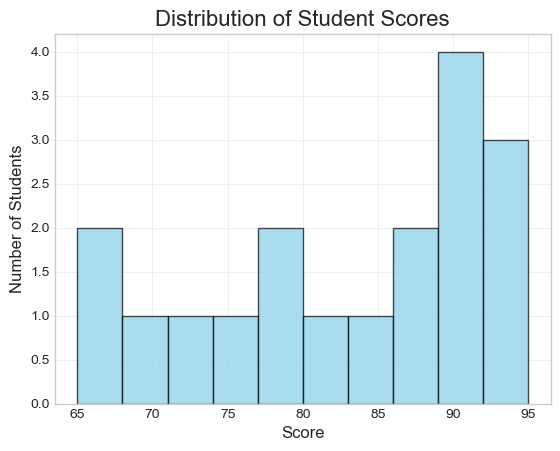

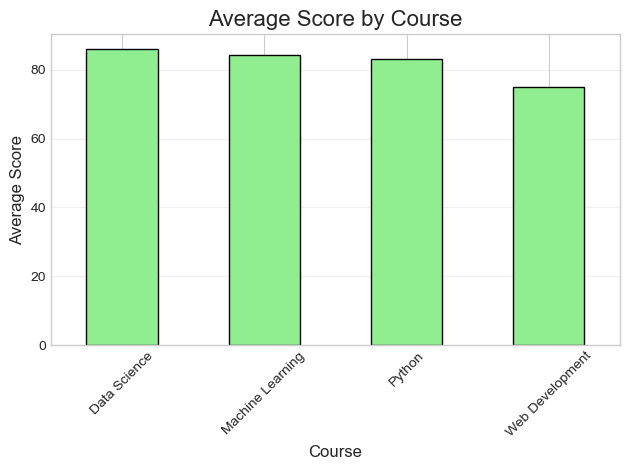

DataFrame with grade categories:
   student_id              name  score grade_category
0        1001       Alice Smith   95.0      Excellent
1        1002       Bob Johnson   82.0           Good
2        1003  Charlie Williams    NaN       No Score
3        1004       David Brown   91.0      Excellent
4        1005         Eva Davis   65.0  Below Average
5        1006      Frank Miller   88.0           Good
6        1007      Grace Wilson   72.0        Average
7        1008       Henry Moore    NaN       No Score
8        1009        Ivy Taylor   79.0        Average
9        1010     Jack Anderson   93.0      Excellent
Number of students with scores above 80: 11

High performing students:
   student_id           name            course  score grade_category
0        1001    Alice Smith            Python   95.0      Excellent
1        1002    Bob Johnson      Data Science   82.0           Good
3        1004    David Brown  Machine Learning   91.0      Excellent
5        1006   Frank Mill

In [3]:
# 2. Data Manipulation and Enhancement (3 points)
# a. Generate at least two visualizations of the data
# In[3]:

# Visualization 1: Histogram of Student Scores
# //Winston20260413 2314h ; plt.figure(figsize=(10, 6))
plt.hist(df['score'].dropna(), bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Student Scores', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 2: Average Score by Course
# //Winston20260413 2314h ; plt.figure(figsize=(10, 6))
avg_by_course = df.groupby('course')['score'].mean().sort_values(ascending=False)
avg_by_course.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average Score by Course', fontsize=16)
plt.xlabel('Course', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('avg_score_by_course.png', dpi=300, bbox_inches='tight')
plt.show()

# b. Create a new column that categorizes students based on their scores
def categorize_score(score):
    """Categorize scores into grade categories."""
    if pd.isna(score):
        return 'No Score'
    elif score >= 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Below Average'

# Apply the function to create a new column
df['grade_category'] = df['score'].apply(categorize_score)

# Display the DataFrame with the new column
print("DataFrame with grade categories:")
print(df[['student_id', 'name', 'score', 'grade_category']].head(10))

# c. Filter the data to show only students with scores above 80
high_performers = df[df['score'] > 80].copy()
print(f"Number of students with scores above 80: {len(high_performers)}")
print("\nHigh performing students:")
print(high_performers[['student_id', 'name', 'course', 'score', 'grade_category']].head())

# d. Check for and handle any missing values in the dataset
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Count missing scores
missing_scores_count = df['score'].isnull().sum()
print(f"\nNumber of students with missing scores: {missing_scores_count}")

# Handle missing values using mean imputation
mean_score = df['score'].mean()
print(f"Mean score (for imputation): {mean_score:.2f}")

# Create a new column with filled scores
df['score_filled'] = df['score'].fillna(mean_score)

# Create grade category based on filled scores
df['grade_category_filled'] = df['score_filled'].apply(categorize_score)

# Verify no missing values in the new column
print("\nMissing values after imputation:")
print(df[['score', 'score_filled']].isnull().sum())

# Display some examples of rows with imputed values
missing_score_examples = df[df['score'].isnull()].head()
print("\nExamples of rows with imputed scores:")
print(missing_score_examples[['student_id', 'name', 'score', 'score_filled', 'grade_category_filled']])

# e. Create a function to calculate the average score for each course
def get_course_averages(dataframe, score_column='score'):
    """
    Calculate the average score for each course.

    Parameters:
    -----------
    dataframe : pandas.DataFrame
        The student dataframe
    score_column : str, optional
        The name of the score column to use (default: 'score')

    Returns:
    --------
    pandas.DataFrame
        DataFrame with course names and their average scores
    """
    # Group by course and calculate mean score
    averages = dataframe.groupby('course')[score_column].mean().reset_index()

    # Rename columns for clarity
    averages.columns = ['Course', 'Average Score']

    # Sort by average score in descending order
    averages = averages.sort_values('Average Score', ascending=False)

    return averages

# Calculate averages for both original and filled scores
course_avg_original = get_course_averages(df)
course_avg_filled = get_course_averages(df, 'score_filled')

print("Course averages (with missing values):")
print(course_avg_original)

print("\nCourse averages (after handling missing values):")
print(course_avg_filled)

# f. Display summary statistics of the data
# Basic summary statistics by course
summary_by_course = df.groupby('course')['score_filled'].agg(['count', 'mean', 'std', 'min', 'max'])
summary_by_course = summary_by_course.rename(columns={
    'count': 'Number of Students',
    'mean': 'Average Score',
    'std': 'Standard Deviation',
    'min': 'Minimum Score',
    'max': 'Maximum Score'
})

print("Summary Statistics by Course:")
print(summary_by_course)

# Grade distribution
grade_counts = df['grade_category_filled'].value_counts()
grade_percentages = df['grade_category_filled'].value_counts(normalize=True) * 100

print("\nGrade Distribution:")
for grade in ['Excellent', 'Good', 'Average', 'Below Average']:
    if grade in grade_counts:
        count = grade_counts[grade]
        percentage = grade_percentages[grade]
        print(f"{grade}: {count} students ({percentage:.1f}%)")

# Average age by course
avg_age_by_course = df.groupby('course')['age'].mean().sort_values()
print("\nAverage Age by Course:")
print(avg_age_by_course)



In [4]:
# 4. Control Structures Implementation (4.5 points)
# a. Implement conditional statements to process student data (1.5 points)
print("\n--- Student Performance Analysis ---")
for i, row in df.head().iterrows():
    # Check if score is missing
    if pd.isna(row['score']):
        print(f"{row['name']} has no score recorded.")
        continue

    # Analyze performance based on score
    if row['score'] >= 90:
        performance = "excellent"
        action = "eligible for honors program"
    elif row['score'] >= 80:
        performance = "good"
        action = "on track"
    elif row['score'] >= 70:
        performance = "average"
        action = "could benefit from additional practice"
    else:
        performance = "below average"
        action = "needs tutoring support"

    # Print the analysis
    print(f"{row['name']} in {row['course']} has {performance} performance and is {action}.")


# b. Use loops to iterate through the dataset and perform operations (1.5 points)
print("\n--- Course Statistics Using Loops ---")
course_stats = {}

# For loop to calculate statistics by course
for course_name in df['course'].unique():
    course_data = df[df['course'] == course_name]

    # Calculate stats manually using loops
    total_score = 0
    count = 0
    max_score = 0
    min_score = 100

    for score in course_data['score_filled']:
        total_score += score
        count += 1

        if score > max_score:
            max_score = score
        if score < min_score:
            min_score = score

    # Store the calculated statistics
    course_stats[course_name] = {
        'count': count,
        'avg_score': total_score / count,
        'max_score': max_score,
        'min_score': min_score
    }

# While loop to display statistics
i = 0
courses = list(course_stats.keys())
while i < len(courses):
    course = courses[i]
    stats = course_stats[course]

    print(f"Course: {course}")
    print(f"  Students: {stats['count']}")
    print(f"  Average Score: {stats['avg_score']:.2f}")
    print(f"  Score Range: {stats['min_score']} - {stats['max_score']}")
    print()

    i += 1


# c. Implement exception handling for potential errors (1.5 points)
print("\n--- Exception Handling Examples ---")

# Example 1: Handle missing values when calculating ratios
print("Calculating pass ratios with error handling:")
try:
    for course in df['course'].unique():
        course_df = df[df['course'] == course]
        try:
            # Count passing students (score >= 70)
            passing = sum(score >= 70 for score in course_df['score_filled'])
            total = len(course_df)

            # This will cause division by zero if total is 0
            pass_ratio = passing / total
            print(f"{course}: {pass_ratio:.1%} passing rate ({passing}/{total})")

        except ZeroDivisionError:
            print(f"{course}: No students enrolled")
        except Exception as e:
            print(f"{course}: Error calculating pass ratio - {e}")

except Exception as e:
    print(f"Unexpected error: {e}")

# Example 2: Handle errors when accessing student records
print("\nAccessing student records safely:")
student_ids_to_find = [1001, 9999, "ABC"]

for student_id in student_ids_to_find:
    try:
        print(f"Looking for student ID: {student_id}")

        # Type checking
        if not isinstance(student_id, (int, np.integer)):
            raise TypeError("Student ID must be an integer")

        # Find student by ID
        student = df[df['student_id'] == student_id]

        # Check if student exists
        if len(student) == 0:
            raise ValueError(f"No student found with ID {student_id}")

        # Access student information
        name = student.iloc[0]['name']
        score = student.iloc[0]['score_filled']

        print(f"Found: {name} with score {score:.1f}")

    except TypeError as e:
        print(f"Type error: {e}")
    except ValueError as e:
        print(f"Value error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")




--- Student Performance Analysis ---
Alice Smith in Python has excellent performance and is eligible for honors program.
Bob Johnson in Data Science has good performance and is on track.
Charlie Williams has no score recorded.
David Brown in Machine Learning has excellent performance and is eligible for honors program.
Eva Davis in Python has below average performance and is needs tutoring support.

--- Course Statistics Using Loops ---
Course: Python
  Students: 5
  Average Score: 83.20
  Score Range: 65.0 - 95.0

Course: Data Science
  Students: 5
  Average Score: 86.00
  Score Range: 75.0 - 93.0

Course: Web Development
  Students: 5
  Average Score: 76.48
  Score Range: 68.0 - 83.0

Course: Machine Learning
  Students: 5
  Average Score: 83.88
  Score Range: 67.0 - 91.0


--- Exception Handling Examples ---
Calculating pass ratios with error handling:
Python: 80.0% passing rate (4/5)
Data Science: 100.0% passing rate (5/5)
Web Development: 80.0% passing rate (4/5)
Machine Learning


--- Advanced Data Analysis by Course ---
Grade distribution by course (%):
grade_category_filled  Average  Below Average  Excellent  Good
course                                                        
Data Science              20.0            0.0       40.0  40.0
Machine Learning           0.0           20.0       40.0  40.0
Python                    20.0           20.0       40.0  20.0
Web Development           40.0           20.0        0.0  40.0

Score analysis by course and age group:
                           student_id score_filled            
                                count         mean   min   max
course           age_group                                    
Data Science     18-20              3         87.7  82.0  93.0
                 21-25              2         83.5  75.0  92.0
                 26-30              0          NaN   NaN   NaN
                 31-35              0          NaN   NaN   NaN
Machine Learning 18-20              1         90.0  90.0  90.0
 

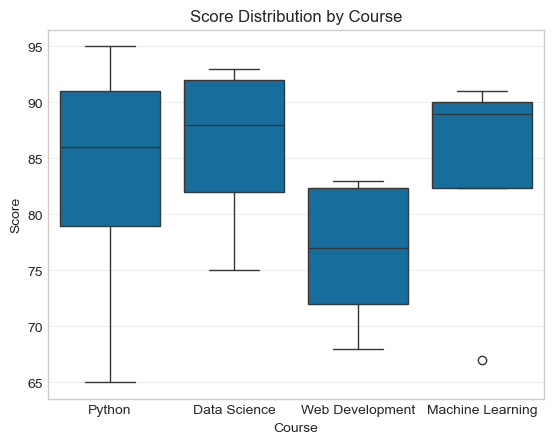

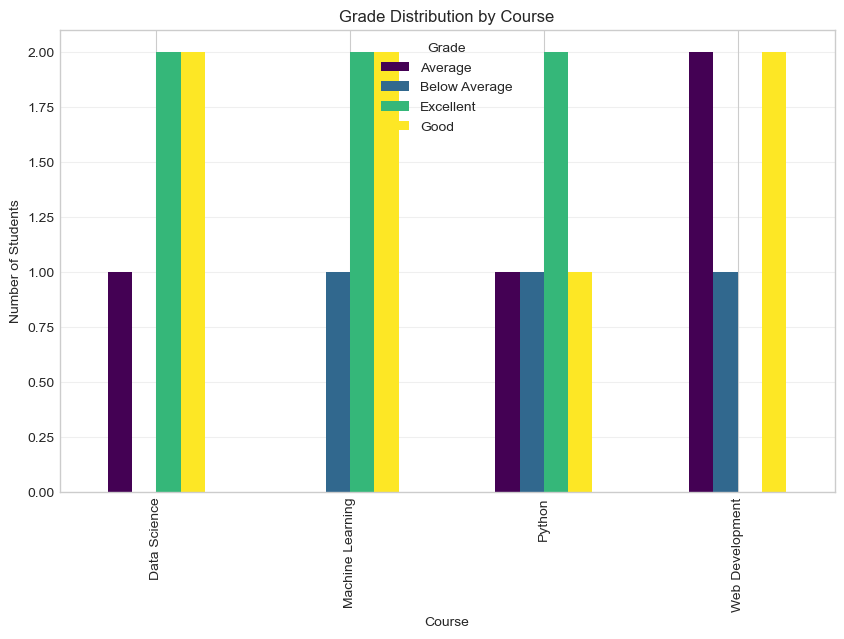

In [5]:
# 5. Advanced Data Analysis (2 points)
# a. Use pandas functions to group and analyze the data by course (1 point)
print("\n--- Advanced Data Analysis by Course ---")

# Create age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[17, 20, 25, 30, 35],
                         labels=['18-20', '21-25', '26-30', '31-35'])

# Group data by course and grade category
course_grade_analysis = pd.crosstab(
    df['course'],
    df['grade_category_filled'],
    normalize='index'
) * 100

print("Grade distribution by course (%):")
print(course_grade_analysis.round(1))

# Group by course and age group for deeper analysis
age_course_analysis = df.groupby(['course', 'age_group'], observed=False).agg({
    'student_id': 'count',
    'score_filled': ['mean', 'min', 'max']
}).round(1)

print("\nScore analysis by course and age group:")
print(age_course_analysis)

# Correlation analysis
correlation = df[['age', 'score_filled']].corr()
print("\nCorrelation between age and score:")
print(correlation)


# b. Create visualizations that show the distribution of scores across different courses (1 point)
print("\n--- Creating Score Distribution Visualizations ---")

# Visualization 1: Box plot by course
# //Winston20260413 2249h ; plt.figure(figsize=(10, 6))
sns.boxplot(x='course', y='score_filled', data=df)
plt.title('Score Distribution by Course')
plt.xlabel('Course')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.savefig('score_distribution_by_course.png')
plt.show()

# Visualization 2: Grade distribution by course
grade_counts = pd.crosstab(df['course'], df['grade_category_filled'])

# grade_counts.plot(kind='bar', figsize=(10, 6), colormap='viridis')


# //Winston20260413 2251h ; 
# grade_counts.plot(kind='bar', colormap='viridis')
grade_counts.plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Grade Distribution by Course')
plt.xlabel('Course')
plt.ylabel('Number of Students')
plt.legend(title='Grade')
plt.grid(axis='y', alpha=0.3)
# //Winston20260413 2257h ; plt.tight_layout()
plt.savefig('grade_distribution_by_course.png')
plt.show()

In [6]:
# In[6]:
# --- Introduction to Lambda Functions ---
print("\n--- Introduction to Lambda Functions ---")

# What is a Lambda Function?
# A lambda function is a small anonymous function.
# A lambda function can take any number of arguments, but can only have one expression.
# Syntax: lambda arguments : expression

# Example 1: Simple lambda function to add two numbers
add_two_numbers = lambda x, y: x + y
print(f"1. Adding 5 and 3 using lambda: {add_two_numbers(5, 3)}")

# Example 2: Lambda function with a single argument to square a number
square = lambda x: x * x
print(f"2. Squaring 7 using lambda: {square(7)}")

# Example 3: Using lambda with filter()
# filter() extracts elements from an iterable for which a function returns True.
my_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
even_numbers = list(filter(lambda x: x % 2 == 0, my_list))
print(f"3. Even numbers from my_list using filter and lambda: {even_numbers}")

# Example 4: Using lambda with map()
# map() applies a function to all the items in an input_list.
doubled_numbers = list(map(lambda x: x * 2, my_list))
print(f"4. Doubled numbers from my_list using map and lambda: {doubled_numbers}")

# Example 5: Using lambda with sorted() for custom sorting
students = [('Alice', 20, 'Math'), ('Bob', 22, 'Science'), ('Charlie', 19, 'Art')]
# Sort by age (second element of the tuple)
sorted_students_by_age = sorted(students, key=lambda student: student[1])
print(f"5. Students sorted by age using lambda: {sorted_students_by_age}")

# Example 6: Lambda function used in a list comprehension (less common but possible)
# Often, for simple operations, lambda's usage in list comprehensions is redundant.
# Here, we're just showing it's possible.
incremented_list = [ (lambda x: x + 1)(i) for i in my_list ]
print(f"6. Incremented list using lambda in a list comprehension: {incremented_list}")

# When to use lambda functions:
# - When you need a simple function for a short period.
# - As arguments to higher-order functions like map(), filter(), sorted(), or apply() in pandas.
# - When a full function definition (with def keyword) feels too verbose for a simple operation.

# When NOT to use lambda functions:
# - For complex logic requiring multiple expressions or statements.
# - When the function needs a docstring or type hints (for readability and maintainability).
# - If the function will be reused multiple times; a named function is better.


--- Introduction to Lambda Functions ---
1. Adding 5 and 3 using lambda: 8
2. Squaring 7 using lambda: 49
3. Even numbers from my_list using filter and lambda: [2, 4, 6, 8, 10]
4. Doubled numbers from my_list using map and lambda: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
5. Students sorted by age using lambda: [('Charlie', 19, 'Art'), ('Alice', 20, 'Math'), ('Bob', 22, 'Science')]
6. Incremented list using lambda in a list comprehension: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


# User
--- Creating Score Distribution Visualizations ---
/tmp/ipykernel_7467/2804528128.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_course_analysis = df.groupby(['course', 'age_group']).agg({

# Assistant
# Creating Score Distribution Visualizations

I notice you're encountering a FutureWarning related to the `observed` parameter in your pandas groupby operation. Let me help you understand this warning and provide a solution for creating score distribution visualizations.

## Understanding the Warning

The warning indicates that the default behavior of `observed=False` in pandas groupby operations is being deprecated. In future pandas versions, `observed=True` will become the default. This parameter affects how categorical data is handled in groupby operations:

- `observed=False`: Include all category combinations in the result, even if they don't appear in the data
- `observed=True`: Include only category combinations that actually appear in the data

## Solution

Here's how to fix the warning and create effective score distribution visualizations:


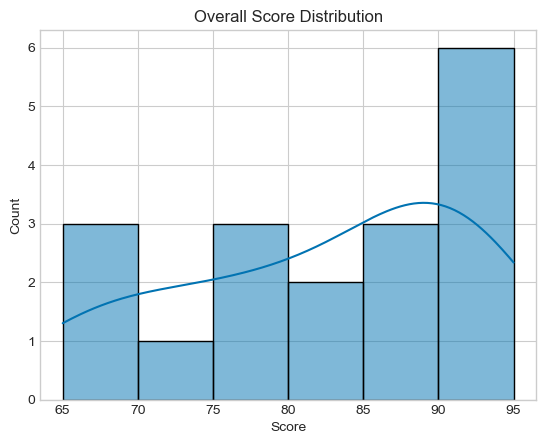

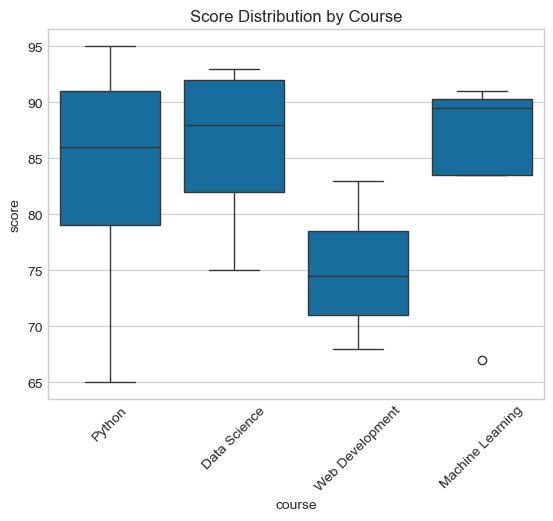

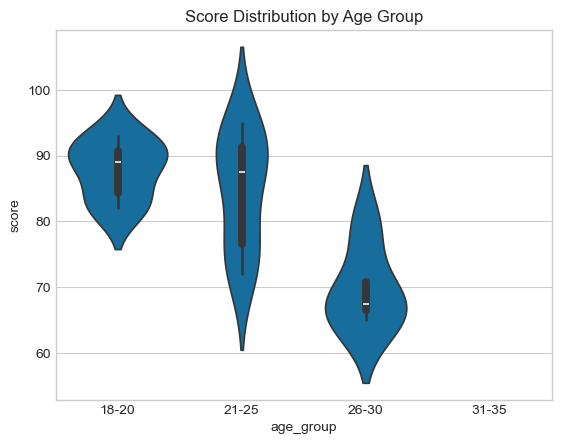

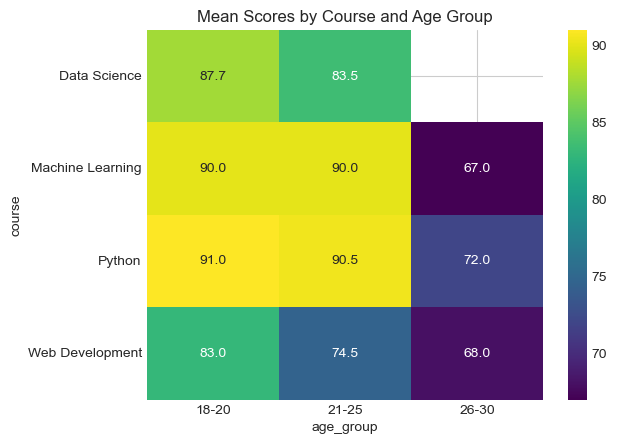

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming df is your dataframe with columns: course, age_group, score (or similar)

# 1. Fix the groupby warning
age_course_analysis = df.groupby(['course', 'age_group'], observed=True).agg({
    'score': ['mean', 'median', 'std', 'count']
}).reset_index()

# 2. Create score distribution visualizations
# //Winston20260413 2240h ; plt.figure(figsize=(12, 8))

# Histogram of scores
# plt.subplot(2, 2, 1)
# //Winston20260413 2240h ; 
# plt.figure(figsize=(12, 8))
sns.histplot(df['score'], kde=True)
plt.title('Overall Score Distribution')
plt.xlabel('Score')
# //Winston20260413 2240h ; 
# plt.tight_layout()
plt.show()

# Box plot by course
# plt.subplot(2, 2, 2)
# //Winston20260413 2240h ; 
# plt.figure(figsize=(12, 8))
sns.boxplot(x='course', y='score', data=df)
plt.title('Score Distribution by Course')
plt.xticks(rotation=45)
# //Winston20260413 2240h ; 
# plt.tight_layout()
plt.show()

# Violin plot by age group
# plt.subplot(2, 2, 3)
# //Winston20260413 2240h ; 
# plt.figure(figsize=(12, 8))
sns.violinplot(x='age_group', y='score', data=df)
plt.title('Score Distribution by Age Group')
# //Winston20260413 2240h ; 
# plt.tight_layout()
plt.show()

# Heatmap of mean scores
# plt.subplot(2, 2, 4)
# //Winston20260413 2240h ; 
# plt.figure(figsize=(12, 8))
# pivot_table = df.pivot_table(index='course', columns='age_group', values='score', aggfunc='mean')

# If you want to keep current behavior (include all possible combinations)
pivot_table126 = df.pivot_table(
    index='course', 
    columns='age_group', 
    values='score', 
    aggfunc='mean',
    observed=False
)

sns.heatmap(pivot_table126, annot=True, cmap='viridis', fmt='.1f')
plt.title('Mean Scores by Course and Age Group')

# plt.tight_layout()
plt.show()

# User
"""
C:\Users\Wi\AppData\Local\Temp\ipykernel_22408\1961998217.py:35: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index='course', columns='age_group', values='score', aggfunc='mean')
"""

# Assistant
# Understanding the FutureWarning in Pandas Pivot Table

This warning is related to how pandas handles categorical data in pivot tables. Let me explain what's happening and how to fix it.

## The Warning Explained

The warning is telling you that:

1. You're using `pivot_table()` without specifying the `observed` parameter
2. The current default is `observed=False`, but in a future pandas version, it will change to `observed=True`
3. To maintain your current behavior in future pandas versions, you should explicitly set `observed=False`

## What does the `observed` parameter do?

- When `observed=False`: The pivot table includes all combinations of categories in the index/columns, even if they don't appear in the data
- When `observed=True`: The pivot table only includes category combinations that actually appear in your data

## How to Fix It

Simply add the `observed` parameter to your pivot_table call:


In [8]:
# If you want to keep current behavior (include all possible combinations)
pivot_table126 = df.pivot_table(
    index='course', 
    columns='age_group', 
    values='score', 
    aggfunc='mean',
    observed=False
)

# OR if you only want combinations that exist in your data
pivot_table138 = df.pivot_table(
    index='course', 
    columns='age_group', 
    values='score', 
    aggfunc='mean',
    observed=True
)


Choose the option that makes sense for your analysis. If you want to see all possible combinations of courses and age groups (including empty ones), use `observed=False`. If you only want to see combinations that exist in your data, use `observed=True`.

## Useful Pandas Packages for Data Analysis

If you're working with pandas for data analysis, you might find these packages helpful:
- `pandas-profiling`: For automated exploratory data analysis
- `plotly` and `seaborn`: For enhanced data visualization
- `scikit-learn`: For machine learning integration with pandas
- `pandas-gbq`: For Google BigQuery integration
- `pandasql`: For SQL-like queries on pandas DataFrames


## Recommended Packages for Score Visualizations

For creating effective score distribution visualizations, I recommend:

1. **pandas**: For data manipulation and analysis
2. **matplotlib**: For creating basic plots and customizing visualizations
3. **seaborn**: For statistical visualizations with better aesthetics
4. **numpy**: For numerical operations
5. **plotly**: For interactive visualizations (especially useful for dashboards)
6. **scipy**: For additional statistical functions

The code above addresses your warning while providing a comprehensive set of visualizations to understand score distributions across different courses and age groups.

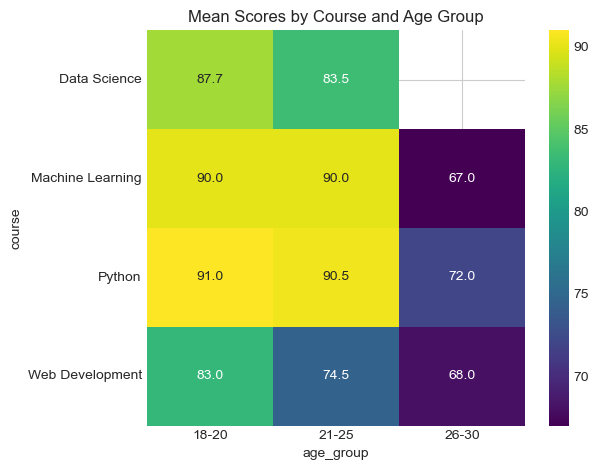

In [9]:
# OR if you only want combinations that exist in your data
pivot_table138 = df.pivot_table(
    index='course', 
    columns='age_group', 
    values='score', 
    aggfunc='mean',
    observed=True
)

sns.heatmap(pivot_table126, annot=True, cmap='viridis', fmt='.1f')
plt.title('Mean Scores by Course and Age Group')

plt.tight_layout()
plt.show()